In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, confusion_matrix, classification_report
import joblib
import pickle

df = pd.read_csv('smart_factory_dataset.csv')
print(df.head())

X = df[['RPM']]
y = df['Temperature']

  Machine_ID      RPM  Vibration  Pressure Machine_Mode  Temperature  \
0   MCH-0001  1811.26      1.888     33.55   High-Speed        83.64   
1   MCH-0002  3366.93      4.564     32.23          Eco        93.72   
2   MCH-0003  2776.38      7.047     91.56          Eco       101.70   
3   MCH-0004  2416.38      5.992     32.46   High-Speed       109.78   
4   MCH-0005  1221.25      6.549     34.48     Standard        76.61   

   Defective  
0          0  
1          0  
2          1  
3          0  
4          0  


MSE (Simple LR): 211.40


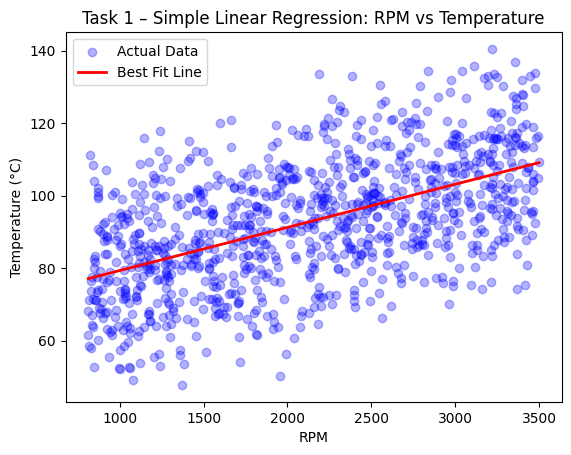

In [3]:
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

mse = mean_squared_error(y, y_pred)
print(f"MSE (Simple LR): {mse:.2f}")

plt.scatter(df['RPM'], y, alpha=0.3, color='blue', label='Actual Data')
plt.plot(df['RPM'].sort_values(),
         model.predict(df[['RPM']].sort_values(by='RPM')),
         color='red', linewidth=2, label='Best Fit Line')
plt.xlabel('RPM')
plt.ylabel('Temperature (°C)')
plt.title('Task 1 – Simple Linear Regression: RPM vs Temperature')
plt.legend()
plt.show()

In [4]:
X_multi = df[['RPM', 'Vibration', 'Pressure']]
y = df['Temperature']

model_multi = LinearRegression()
model_multi.fit(X_multi, y)
y_pred_multi = model_multi.predict(X_multi)

mse_multi = mean_squared_error(y, y_pred_multi)
print(f"MSE (Simple LR)       : 211.40")
print(f"MSE (Multivariable LR): {mse_multi:.2f}")
print(f"Improvement           : {211.40 - mse_multi:.2f} reduction")

joblib.dump(model_multi, 'model_temperature.joblib')
print("Model saved with joblib ")

with open('model_temperature.pkl', 'wb') as f:
    pickle.dump(model_multi, f)
print("Model saved with pickle ")

MSE (Simple LR)       : 211.40
MSE (Multivariable LR): 131.23
Improvement           : 80.17 reduction
Model saved with joblib 
Model saved with pickle 


In [5]:
loaded_model = joblib.load('model_temperature.joblib')

new_machine = pd.DataFrame({
    'RPM':       [2000],
    'Vibration': [2.5],
    'Pressure':  [60]
})

predicted_temp = loaded_model.predict(new_machine)[0]
print(f"\nNew Machine Reading:")
print(f"  RPM=2000, Vibration=2.5, Pressure=60")
print(f"  Predicted Temperature: {predicted_temp:.1f} °C")

df_encoded = pd.get_dummies(df, columns=['Machine_Mode'], drop_first=True)

df_encoded['Machine_Mode_High-Speed'] = df_encoded['Machine_Mode_High-Speed'].astype(int)
df_encoded['Machine_Mode_Standard']   = df_encoded['Machine_Mode_Standard'].astype(int)

print("Before encoding columns:", list(df.columns))
print("After encoding columns :", list(df_encoded.columns))
print()
print(df_encoded.head())


New Machine Reading:
  RPM=2000, Vibration=2.5, Pressure=60
  Predicted Temperature: 89.2 °C
Before encoding columns: ['Machine_ID', 'RPM', 'Vibration', 'Pressure', 'Machine_Mode', 'Temperature', 'Defective']
After encoding columns : ['Machine_ID', 'RPM', 'Vibration', 'Pressure', 'Temperature', 'Defective', 'Machine_Mode_High-Speed', 'Machine_Mode_Standard']

  Machine_ID      RPM  Vibration  Pressure  Temperature  Defective  \
0   MCH-0001  1811.26      1.888     33.55        83.64          0   
1   MCH-0002  3366.93      4.564     32.23        93.72          0   
2   MCH-0003  2776.38      7.047     91.56       101.70          1   
3   MCH-0004  2416.38      5.992     32.46       109.78          0   
4   MCH-0005  1221.25      6.549     34.48        76.61          0   

   Machine_Mode_High-Speed  Machine_Mode_Standard  
0                        1                      0  
1                        0                      0  
2                        0                      0  
3       

In [6]:


X = df_encoded[['RPM', 'Vibration', 'Pressure', 'Machine_Mode_High-Speed', 'Machine_Mode_Standard']]
y = df_encoded['Temperature']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total rows    : {len(df_encoded)}")
print(f"Training rows : {len(X_train)}")
print(f"Testing rows  : {len(X_test)}")

model_split = LinearRegression()
model_split.fit(X_train, y_train)

mse_train = mean_squared_error(y_train, model_split.predict(X_train))
mse_test  = mean_squared_error(y_test,  model_split.predict(X_test))

print(f"\nMSE on Training data : {mse_train:.2f}")
print(f"MSE on Testing data  : {mse_test:.2f}")

X = df_encoded[['RPM', 'Vibration', 'Pressure', 'Machine_Mode_High-Speed', 'Machine_Mode_Standard']]
y = df_encoded['Defective']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_logistic = LogisticRegression(max_iter=1000)
model_logistic.fit(X_train, y_train)
y_pred = model_logistic.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))


Total rows    : 1000
Training rows : 800
Testing rows  : 200

MSE on Training data : 24.86
MSE on Testing data  : 21.64
Confusion Matrix:
[[72 34]
 [20 74]]

              precision    recall  f1-score   support

           0       0.78      0.68      0.73       106
           1       0.69      0.79      0.73        94

    accuracy                           0.73       200
   macro avg       0.73      0.73      0.73       200
weighted avg       0.74      0.73      0.73       200

